## **3.1 Forward Selection** <a class="anchor" id="3.1"></a>

[Table of Contents](#0.1) 


- Forward selection is an iterative method in which we start with having no feature in the model. In each iteration, we keep adding the feature which best improves our model till an addition of a new variable does not improve the performance of the model.

- The procedure starts with an empty set of features [reduced set]. The best of the original features is determined and added to the reduced set. At each subsequent iteration, the best of the remaining original attributes is added to the set.

- Step forward feature selection starts by evaluating all features individually and selects the one that generates the best performing algorithm, according to a pre-set evaluation criteria. In the second step, it evaluates all possible combinations of the selected feature and a second feature, and selects the pair that produce the best performing algorithm based on the same pre-set criteria.

- The pre-set criteria can be the roc_auc for classification and the r squared for regression for example.

- This selection procedure is called greedy, because it evaluates all possible single, double, triple and so on feature combinations. Therefore, it is quite computationally expensive, and sometimes, if feature space is big, even unfeasible.

- There is a special package for python that implements this type of feature selection: mlxtend.

- In the mlxtend implementation of the step forward feature selection, the stopping criteria is an arbitrarily set number of features. So the search will finish when we reach the desired number of selected features.

- I will demonstrate the Step Forward feature selection algorithm from mlxtend using the House Price dataset.

In [11]:
# !pip install mlxtend

In [ ]:
# step forward feature selection
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
import matplotlib.pyplot as plt

In [13]:
#load dataset
data = pd.read_csv('train.csv')
data.shape

(1460, 81)

In [14]:
# In practice, feature selection should be done after data pre-processing,
# so ideally, all the categorical variables are encoded into numbers,
# and then you can assess how deterministic they are of the target

# here for simplicity I will use only numerical variables
# select numerical columns:

numerics = ['int16', 'int32', 'int64', 'float16', 'float32', 'float64']
numerical_vars = list(data.select_dtypes(include=numerics).columns)
data = data[numerical_vars]
data.shape

(1460, 38)

In [15]:
# separate train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    data.drop(labels=['SalePrice'], axis=1),
    data['SalePrice'],
    test_size=0.3,
    random_state=0
)

X_train.shape, X_test.shape

((1022, 37), (438, 37))

In [16]:
# find and remove correlated features
def correlation(dataset, threshold):
    col_corr = set()  # Set of all the names of correlated columns
    corr_matrix = dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i, j]) > threshold: # we are interested in absolute coeff value
                colname = corr_matrix.columns[i]  # getting the name of column
                col_corr.add(colname)
    return col_corr

corr_features = correlation(X_train, 0.8)
print('correlated features: ', len(set(corr_features)) )
print('correlated features: ', set(corr_features) )

correlated features:  3
correlated features:  {'GarageYrBlt', 'GarageArea', 'TotRmsAbvGrd'}


In [17]:
# removed correlated  features
X_train.drop(labels=corr_features, axis=1, inplace=True)
X_test.drop(labels=corr_features, axis=1, inplace=True)
X_train.shape, X_test.shape

((1022, 34), (438, 34))

In [18]:
X_train.fillna(0, inplace=True)

In [19]:
from mlxtend.feature_selection import SequentialFeatureSelector as SFS

sfs1 = SFS(RandomForestRegressor(), 
           k_features=10, 
           forward=True, 
           floating=False, 
           verbose=2,
           scoring='r2',
           cv=3)

sfs1 = sfs1.fit(np.array(X_train), y_train)


[2025-05-07 11:24:49] Features: 1/10 -- score: 0.6679802644043727
[2025-05-07 11:25:08] Features: 2/10 -- score: 0.7210020150792049
[2025-05-07 11:25:28] Features: 3/10 -- score: 0.7452561180606714
[2025-05-07 11:25:47] Features: 4/10 -- score: 0.761248655167905
[2025-05-07 11:26:07] Features: 5/10 -- score: 0.7695077956531681
[2025-05-07 11:26:25] Features: 6/10 -- score: 0.7702178262130895
[2025-05-07 11:26:46] Features: 7/10 -- score: 0.7897261016666488
[2025-05-07 11:27:13] Features: 8/10 -- score: 0.8254288344781665
[2025-05-07 11:27:45] Features: 9/10 -- score: 0.8342717187742981
[2025-05-07 11:28:17] Features: 10/10 -- score: 0.8454339749378263

In [20]:
# Si X_train es un DataFrame con nombres de columnas:
selected_features = list(sfs1.k_feature_names_)
print("Características seleccionadas:", selected_features)

Características seleccionadas: ['4', '5', '6', '12', '14', '16', '17', '19', '22', '24']


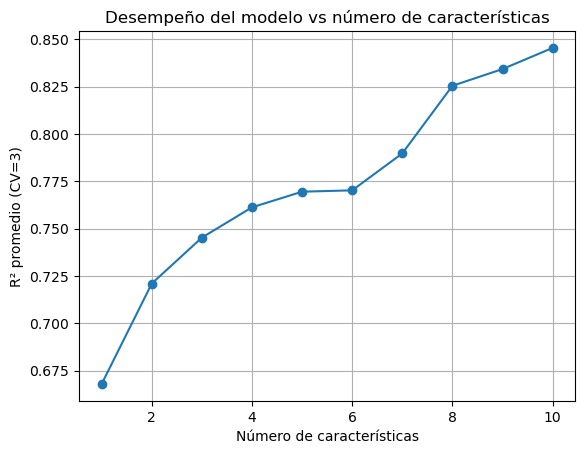

In [ ]:
# Extrae número de características y su rendimiento
k_feat = [k for k in sfs1.subsets_]
scores = [sfs1.subsets_[k]['avg_score'] for k in sfs1.subsets_]

# Gráfica
plt.plot(k_feat, scores, marker='o')
plt.title('Desempeño del modelo vs número de características')
plt.xlabel('Número de características')
plt.ylabel('R² promedio (CV=3)')
plt.grid()
plt.show()
